# Customer Segmentation using K-Means

## Project Goal
The goal of this project is to segment customers based on their purchasing behavior.

Using the K-Means clustering algorithm, we analyze customer data such as:

- Annual Income
- Spending Score

The objective is to identify meaningful customer groups that can help businesses improve marketing strategies and customer targeting.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("Libraries loaded successfully")

In [3]:
X = df[['Annual_Income','Spending_Score']]

X

,Annual_Income,Spending_Score
0,15,39
1,16,81
2,17,6
3,18,77
4,19,40
5,20,76
6,21,6
7,22,94
8,23,3
9,24,72


In [9]:
import numpy as np

np.random.seed(42)

data = {
    "Annual_Income": np.random.randint(15,100,200),
    "Spending_Score": np.random.randint(1,100,200)
}

df = pd.DataFrame(data)

df.head()

,Annual_Income,Spending_Score
0,66,56
1,29,17
2,86,38
3,75,24
4,35,69


In [10]:
X = df[['Annual_Income','Spending_Score']]

kmeans = KMeans(n_clusters=5)

kmeans.fit(X)

df['Cluster'] = kmeans.labels_

df.head()

,Annual_Income,Spending_Score,Cluster
0,66,56,0
1,29,17,4
2,86,38,0
3,75,24,2
4,35,69,1


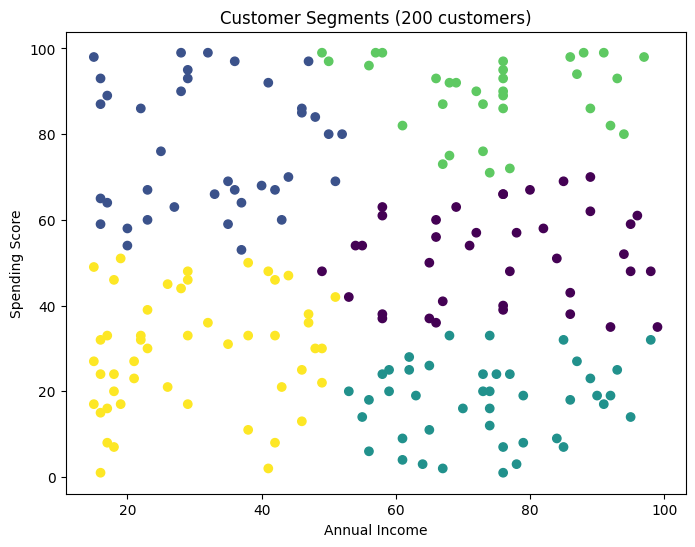

In [11]:

plt.figure(figsize=(8,6))

plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title("Customer Segments (200 customers)")

plt.show()

In [12]:
cluster_names = {
0:"Budget Customers",
1:"High Value Customers",
2:"Potential Loyalists",
3:"Low Engagement",
4:"Premium Clients"
}

df["Segment"] = df["Cluster"].map(cluster_names)

df.head()

,Annual_Income,Spending_Score,Cluster,Segment
0,66,56,0,Budget Customers
1,29,17,4,Premium Clients
2,86,38,0,Budget Customers
3,75,24,2,Potential Loyalists
4,35,69,1,High Value Customers


In [13]:
df.groupby("Segment").mean()

,Annual_Income,Spending_Score,Cluster
Segment,,,
Budget Customers,75.236842,51.657895,0.0
High Value Customers,32.052632,76.526316,1.0
Low Engagement,74.312500,89.343750,3.0
Potential Loyalists,73.511628,17.581395,2.0
Premium Clients,29.734694,29.122449,4.0


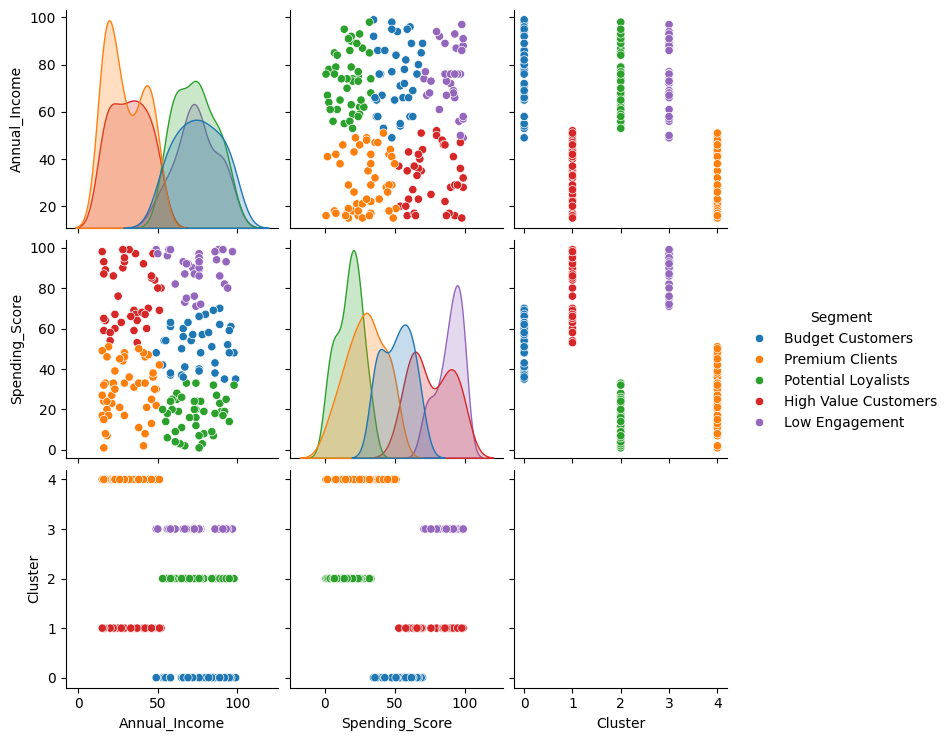

In [14]:
import seaborn as sns

sns.pairplot(df, hue="Segment")

plt.show()

In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, kmeans.labels_)

print("Silhouette Score:", score)

Silhouette Score: 0.3879432996585952


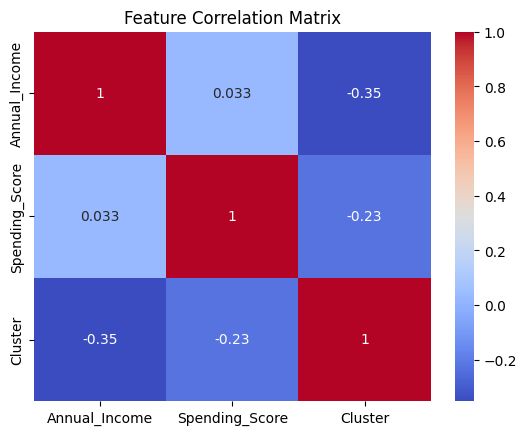

In [16]:
corr = df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

In [17]:
df["Segment"].value_counts()

Segment
Premium Clients         49
Potential Loyalists     43
Budget Customers        38
High Value Customers    38
Low Engagement          32
Name: count, dtype: int64

In [18]:
(df["Segment"].value_counts(normalize=True) * 100).round(2)

Segment
Premium Clients         24.5
Potential Loyalists     21.5
Budget Customers        19.0
High Value Customers    19.0
Low Engagement          16.0
Name: proportion, dtype: float64

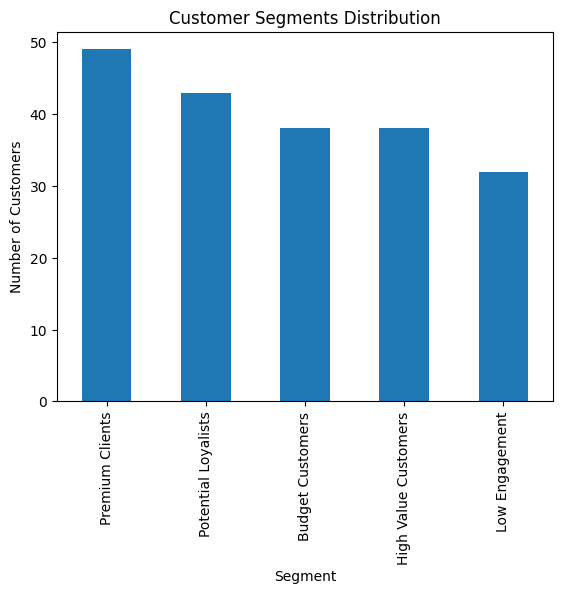

In [19]:
df["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments Distribution")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.show()

In [30]:
segment_summary = df.groupby("Segment").agg({
    "Annual_Income": ["mean","min","max"],
    "Spending_Score": ["mean","min","max"]
}).round(2)

segment_summary

Annual_Income         Spending_Score        
                              mean min max           mean min max
Segment                                                          
Budget Customers             75.24  49  99          51.66  35  70
High Value Customers         32.05  15  52          76.53  53  99
Low Engagement               74.31  49  97          89.34  71  99
Potential Loyalists          73.51  53  98          17.58   1  33
Premium Clients              29.73  15  51          29.12   1  51

In [29]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, kmeans.labels_)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.4


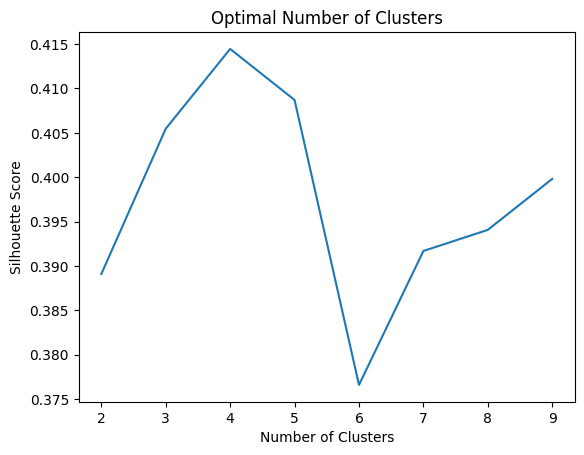

In [27]:
plt.plot(range(2,10), scores)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title("Optimal Number of Clusters")

plt.show()

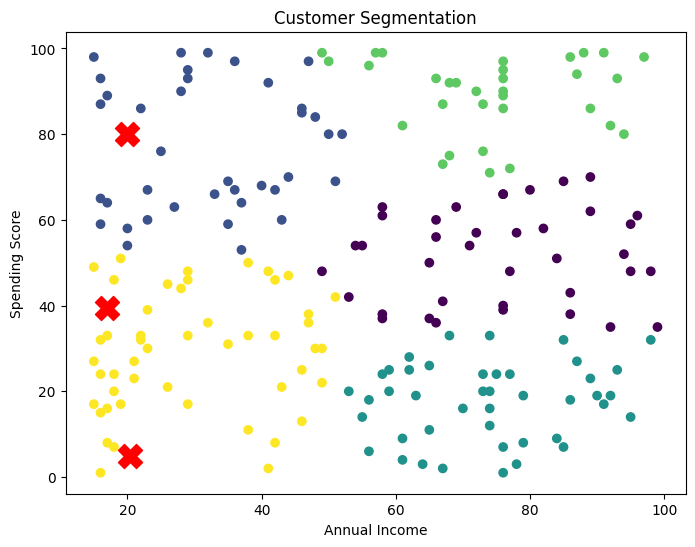

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual_Income'],
    df['Spending_Score'],
    c=df['Cluster']
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=300,
    c='red',
    marker='X'
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

# сохраняем график
plt.savefig("customer_segments.png", dpi=300, bbox_inches="tight")

plt.show()


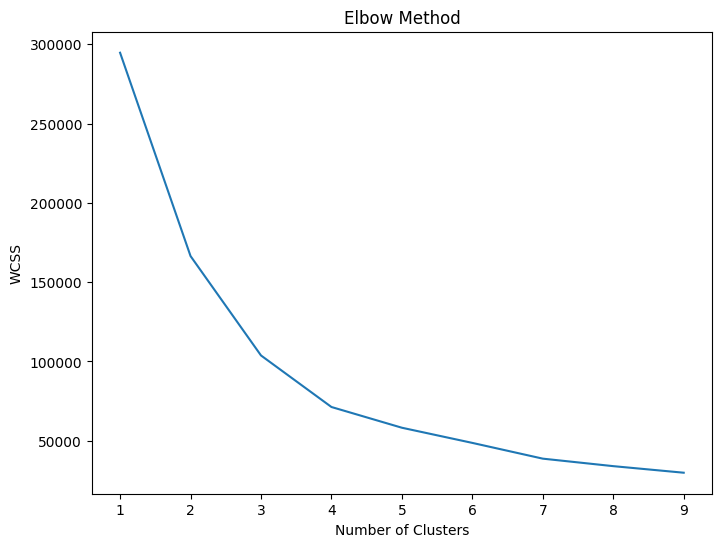

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df[['Annual_Income', 'Spending_Score']]

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))

plt.plot(range(1,10), wcss)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.savefig("elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

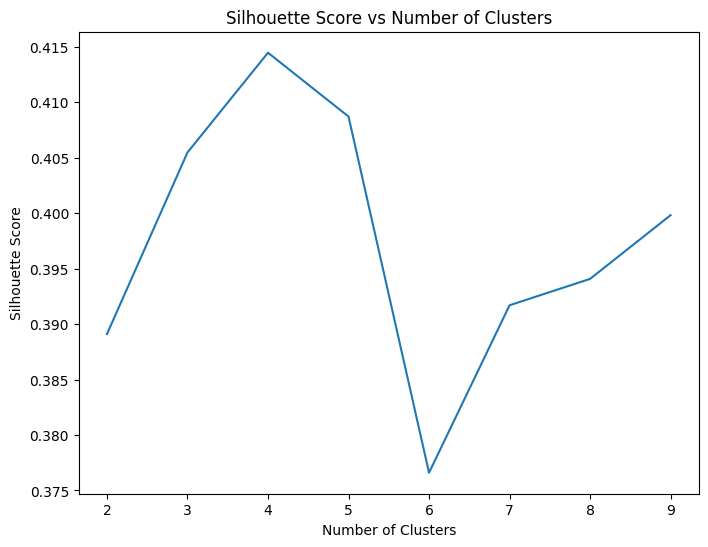

In [24]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df[['Annual_Income', 'Spending_Score']]

scores = []

for k in range(2,10):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    
    score = silhouette_score(X, labels)
    scores.append(score)

plt.figure(figsize=(8,6))

plt.plot(range(2,10), scores)

plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.savefig("silhouette_score.png", dpi=300, bbox_inches="tight")

plt.show()

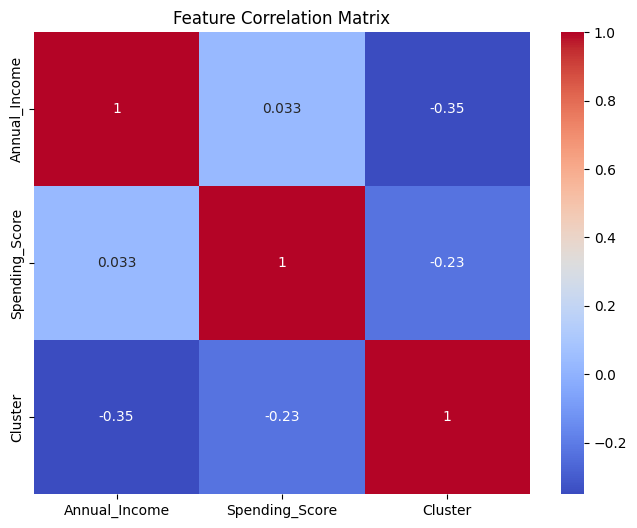

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

corr = df[['Annual_Income','Spending_Score','Cluster']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


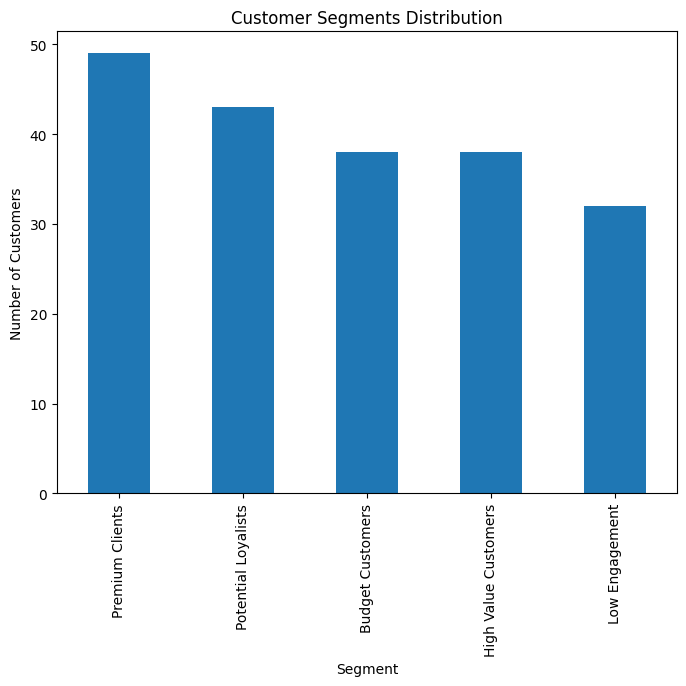

In [22]:

import matplotlib.pyplot as plt

segment_counts = df['Segment'].value_counts()

plt.figure(figsize=(8,6))

segment_counts.plot(kind='bar')

plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.savefig("segment_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Key Insights

Based on clustering analysis, we identified several customer segments:

- Premium Clients – high income and high spending customers
- High Value Customers – strong purchasing behavior
- Potential Loyalists – customers with growth potential
- Budget Customers – lower income with moderate spending
- Low Engagement – customers with low activity

These insights can help businesses:

- personalize marketing campaigns
- improve customer retention strategies
- target high-value customers more effectively